In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Load dataset
df = pd.read_csv('hospital_patient_flow.csv')

# Basic info
print("SHAPE:", df.shape)
print("\nDATATYPES:\n", df.dtypes)
print("\nMISSING VALUES:\n", df.isnull().sum())
print("\nDUPLICATES:", df.duplicated().sum())
df.head()

SHAPE: (60000, 17)

DATATYPES:
 patient_id                 str
age                      int64
gender                     str
state_of_origin            str
department                 str
diagnosis                  str
admission_date             str
admission_time             str
discharge_date             str
length_of_stay_days      int64
outcome                    str
insurance_type             str
total_bill_ngn         float64
amount_paid_ngn        float64
attending_doctor_id        str
ward                       str
readmitted                 str
dtype: object

MISSING VALUES:
 patient_id                 0
age                        0
gender                     0
state_of_origin            0
department                 0
diagnosis                  0
admission_date             0
admission_time             0
discharge_date             0
length_of_stay_days        0
outcome                    0
insurance_type         12122
total_bill_ngn             0
amount_paid_ngn            0
att

,patient_id,age,gender,state_of_origin,department,diagnosis,admission_date,admission_time,discharge_date,length_of_stay_days,outcome,insurance_type,total_bill_ngn,amount_paid_ngn,attending_doctor_id,ward,readmitted
0,PAT-200000,62,Male,Benin City,Orthopedics,Hypertension,2023-02-19,00:00,2023-02-19,0,Still Admitted,Corporate,90000.0,509100.0,DR-066,Ward 9,No
1,PAT-200001,21,Female,Port Harcourt,General Medicine,Kidney Disease,2022-10-27,02:00,2022-11-15,19,Referred,NHIS,455000.0,24000.0,DR-014,Ward 19,No
2,PAT-200002,79,Female,Abuja,Neurology,Hypertension,2022-04-21,06:00,2022-04-27,6,Discharged,NaN,575000.0,265200.0,DR-050,Ward 4,No
3,PAT-200003,16,Male,Lagos,General Medicine,Fracture,2022-06-01,00:00,2022-06-07,6,Still Admitted,NaN,57000.0,585000.0,DR-026,Ward 19,No
4,PAT-200004,47,Female,Lagos,Pediatrics,HIV/AIDS,2021-04-26,21:00,2021-05-20,24,Still Admitted,NHIS,675000.0,128700.0,DR-063,Ward 12,No


In [2]:
# ================================================
# Task 52 — Parse Dates & Calculate bill_gap
# ================================================

# Convert dates from text to datetime
df['admission_date']  = pd.to_datetime(df['admission_date'])
df['discharge_date']  = pd.to_datetime(df['discharge_date'])

# Extract date components from admission_date
df['year']         = df['admission_date'].dt.year
df['month']        = df['admission_date'].dt.month
df['month_name']   = df['admission_date'].dt.strftime('%b')
df['day_of_week']  = df['admission_date'].dt.day_name()
df['hour']         = pd.to_datetime(df['admission_time'], 
                                     format='%H:%M').dt.hour

# Calculate bill_gap
df['bill_gap'] = df['total_bill_ngn'] - df['amount_paid_ngn']

# Handle missing insurance_type
df['insurance_type'] = df['insurance_type'].fillna('Unknown')

# Confirm everything worked
print("Date range:", df['admission_date'].min().date(), 
      "→", df['admission_date'].max().date())
print("Years covered:", sorted(df['year'].unique()))
print("\nBill Gap Summary:")
print(f"Total Billed:    ₦{df['total_bill_ngn'].sum():,.0f}")
print(f"Total Collected: ₦{df['amount_paid_ngn'].sum():,.0f}")
print(f"Total Gap:       ₦{df['bill_gap'].sum():,.0f}")
print("\nMissing values after fix:\n", df.isnull().sum())

df[['patient_id', 'admission_date', 'discharge_date', 
    'total_bill_ngn', 'amount_paid_ngn', 'bill_gap']].head()

Date range: 2021-01-01 → 2024-01-01
Years covered: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Bill Gap Summary:
Total Billed:    ₦24,102,560,000
Total Collected: ₦18,027,616,400
Total Gap:       ₦6,074,943,600

Missing values after fix:
 patient_id             0
age                    0
gender                 0
state_of_origin        0
department             0
diagnosis              0
admission_date         0
admission_time         0
discharge_date         0
length_of_stay_days    0
outcome                0
insurance_type         0
total_bill_ngn         0
amount_paid_ngn        0
attending_doctor_id    0
ward                   0
readmitted             0
year                   0
month                  0
month_name             0
day_of_week            0
hour                   0
bill_gap               0
dtype: int64


,patient_id,admission_date,discharge_date,total_bill_ngn,amount_paid_ngn,bill_gap
0,PAT-200000,2023-02-19,2023-02-19,90000.0,509100.0,-419100.0
1,PAT-200001,2022-10-27,2022-11-15,455000.0,24000.0,431000.0
2,PAT-200002,2022-04-21,2022-04-27,575000.0,265200.0,309800.0
3,PAT-200003,2022-06-01,2022-06-07,57000.0,585000.0,-528000.0
4,PAT-200004,2021-04-26,2021-05-20,675000.0,128700.0,546300.0


## Bill Gap Deep Analysis — Key Finding

- 62.7% of patients (37,607) underpaid totalling ₦10.5 billion
- 37.3% of patients (22,340) overpaid totalling ₦4.4 billion
- Only 3 patients paid the exact billed amount
- Net revenue gap is ₦6.07 billion
- Negative bill_gap values represent overpayments
  and will be retained in the dataset as they 
  represent real financial transactions
- Recommendation: Hospital needs a proper payment
  reconciliation system to track both underpayments
  and overpayments accurately

In [3]:
# ================================================
# Data Quality Check — 2024 Row Investigation
# ================================================

# Count rows per year
print("Rows per year:")
print(df['year'].value_counts().sort_index())

# Check what dates exist in 2024
print("\n2024 dates found:")
print(df[df['year'] == 2024]['admission_date'].value_counts())

Rows per year:
year
2021    19963
2022    19909
2023    20078
2024       50
Name: count, dtype: int64

2024 dates found:
admission_date
2024-01-01    50
Name: count, dtype: int64


In [4]:
# ================================================
# Data Quality Fix — Remove 50 invalid 2024 rows
# Note: 2024 had only 50 rows (likely data entry 
# errors) compared to ~20,000 rows per valid year.
# Decision: Remove 2024 rows to maintain data 
# integrity for 2021-2023 analysis period.
# ================================================

# Remove 2024 rows
df = df[df['year'] != 2024]

# Confirm it's clean
print("Remaining rows:", len(df))
print("Years now:", sorted(df['year'].unique()))

Remaining rows: 59950
Years now: [np.int32(2021), np.int32(2022), np.int32(2023)]


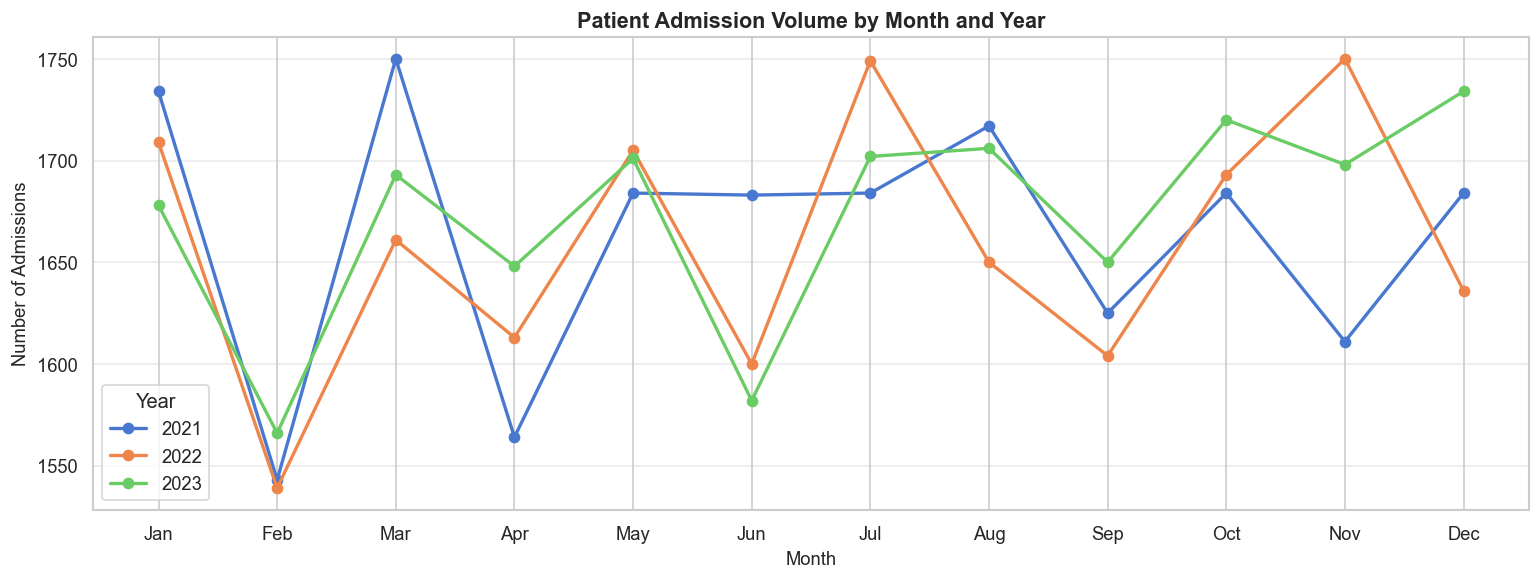

In [5]:
# ================================================
# Task 53 — Patient Admission Volume by Month & Year
# Line chart showing admission trends across years
# ================================================

# Group admissions by year and month
monthly_admissions = (df.groupby(['year', 'month'])
                      .size()
                      .reset_index(name='total_admissions'))

fig, ax = plt.subplots(figsize=(13, 5))

# Plot one line per year
for year, group in monthly_admissions.groupby('year'):
    ax.plot(group['month'], group['total_admissions'],
            marker='o', linewidth=2, label=str(year))

# Formatting
ax.set_title('Patient Admission Volume by Month and Year', 
             fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Admissions')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

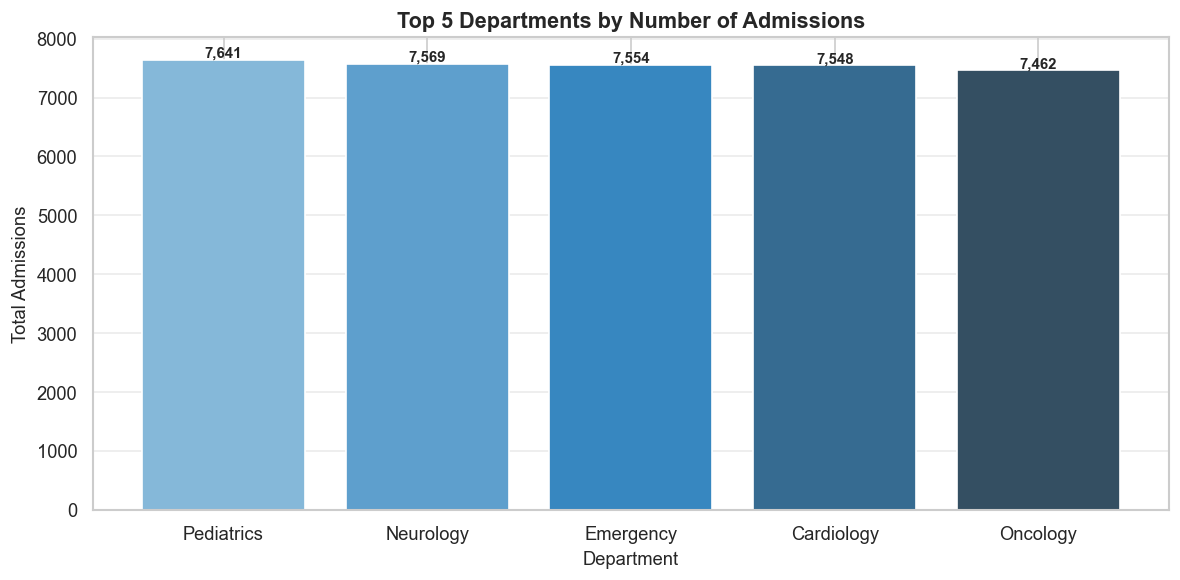

In [6]:
# ================================================
# Task 54 — Top 5 Departments by Admissions
# Bar chart showing busiest hospital departments
# ================================================

# Get top 5 departments by admission count
top5_dept = (df['department']
             .value_counts()
             .nlargest(5)
             .reset_index())
top5_dept.columns = ['department', 'total_admissions']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(top5_dept['department'], 
              top5_dept['total_admissions'],
              color=sns.color_palette('Blues_d', 5))

# Add value labels on top of each bar
for bar, val in zip(bars, top5_dept['total_admissions']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=9,
            fontweight='bold')

ax.set_title('Top 5 Departments by Number of Admissions',
             fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Total Admissions')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

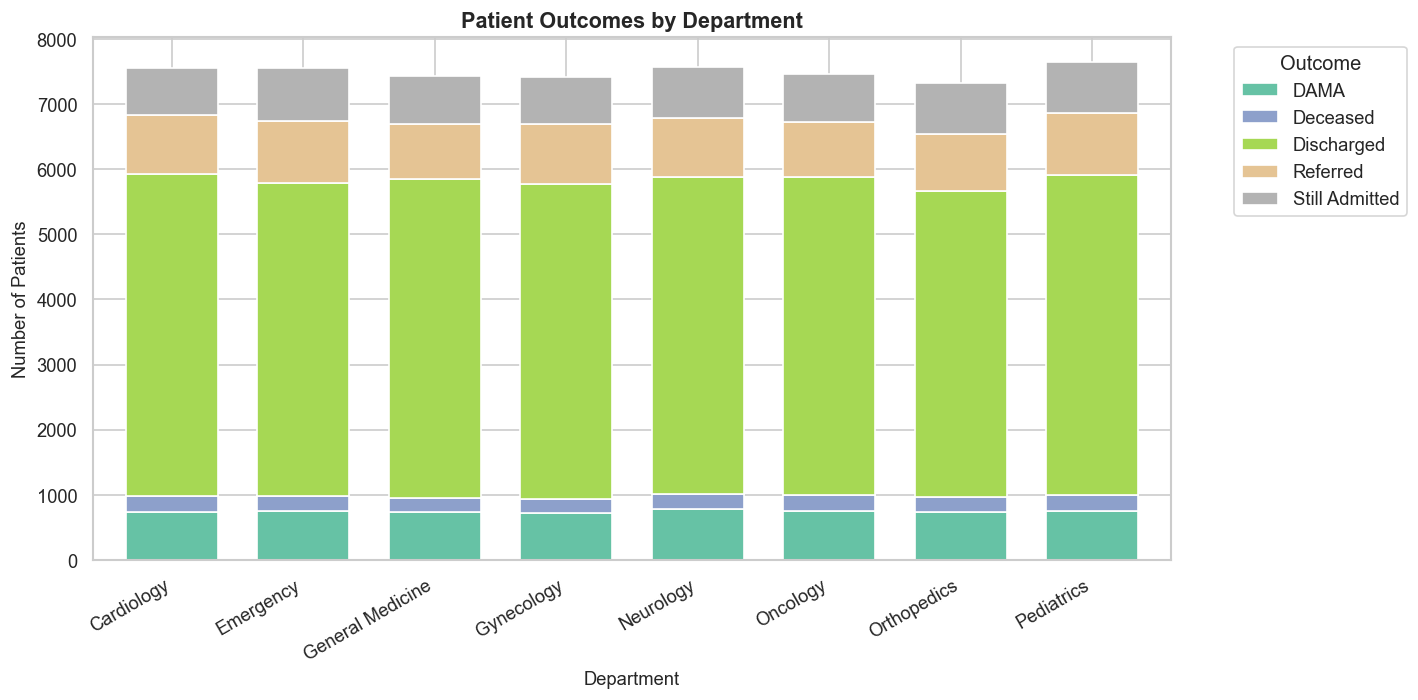

In [7]:
# ================================================
# Task 55 — Stacked Bar Chart: Outcomes by Department
# Shows distribution of patient outcomes per department
# ================================================

# Create crosstab of department vs outcome
outcome_dept = pd.crosstab(df['department'], df['outcome'])

fig, ax = plt.subplots(figsize=(12, 6))

# Plot stacked bar chart
outcome_dept.plot(kind='bar', stacked=True, ax=ax,
                  colormap='Set2', width=0.7)

ax.set_title('Patient Outcomes by Department', 
             fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Number of Patients')
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1), 
          loc='upper left')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

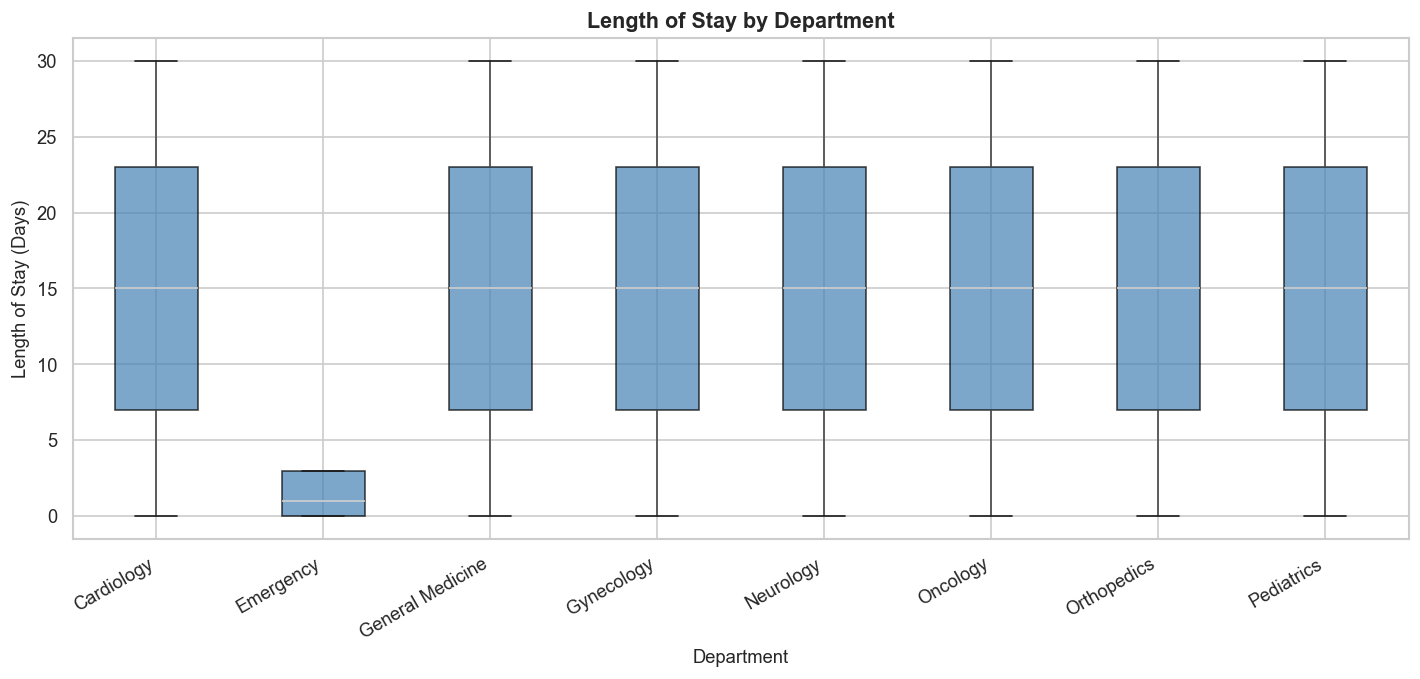

In [8]:
# ================================================
# Task 56 — Box Plot: Length of Stay by Department
# Shows spread of how long patients stay per department
# ================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Create box plot
df.boxplot(column='length_of_stay_days', 
           by='department',
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))

ax.set_title('Length of Stay by Department', 
             fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Length of Stay (Days)')
plt.suptitle('')  # removes default pandas subtitle
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

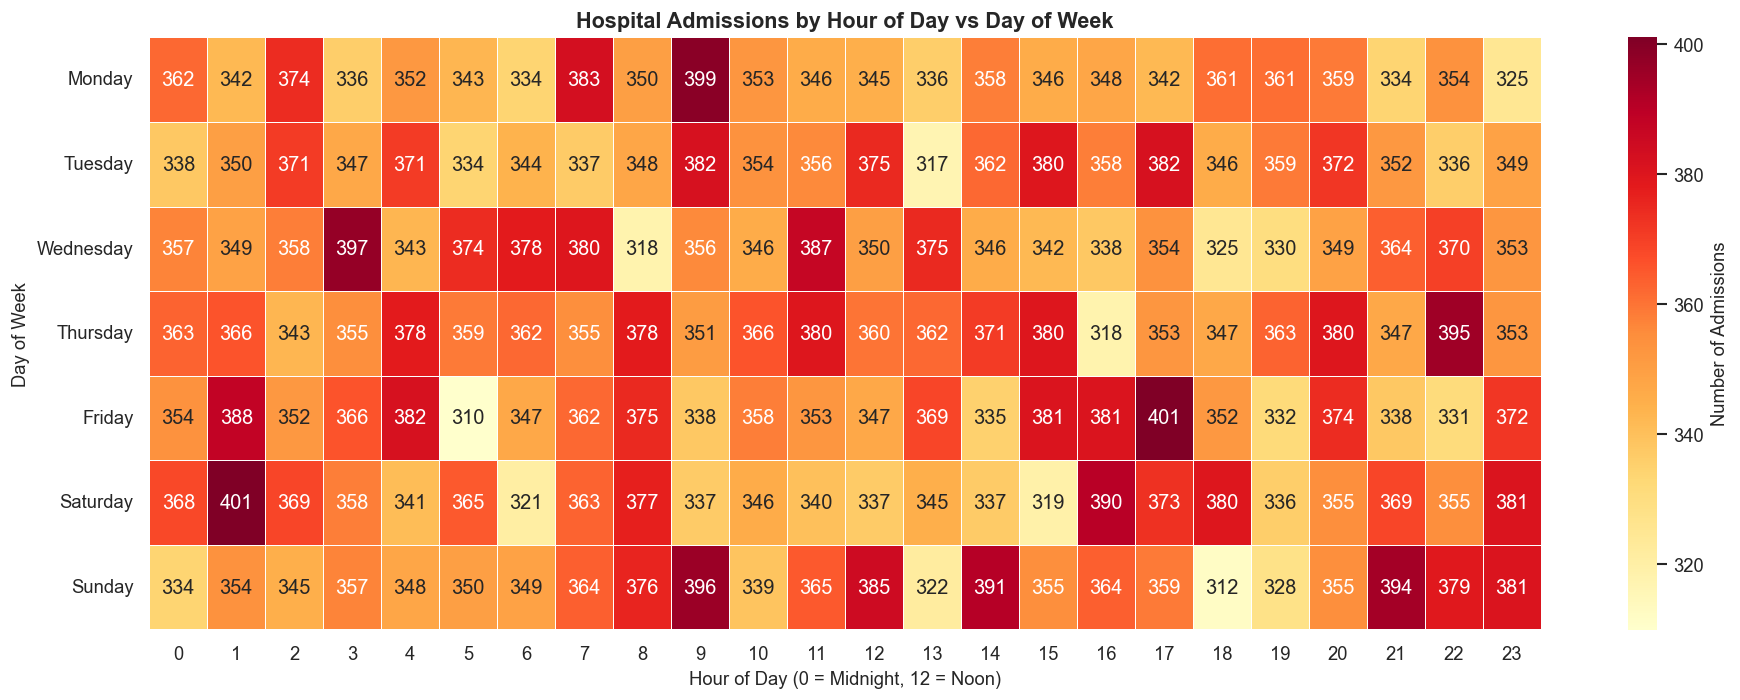

In [9]:
# ================================================
# Task 57 — Heatmap: Admissions by Hour vs Day of Week
# Identifies peak admission periods in the hospital
# ================================================

# Create pivot table: hour vs day of week
# Define correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (df.groupby(['day_of_week', 'hour'])
                .size()
                .reset_index(name='admissions')
                .pivot(index='day_of_week', 
                       columns='hour', 
                       values='admissions'))

# Reorder days correctly
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Number of Admissions'})

ax.set_title('Hospital Admissions by Hour of Day vs Day of Week',
             fontweight='bold')
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

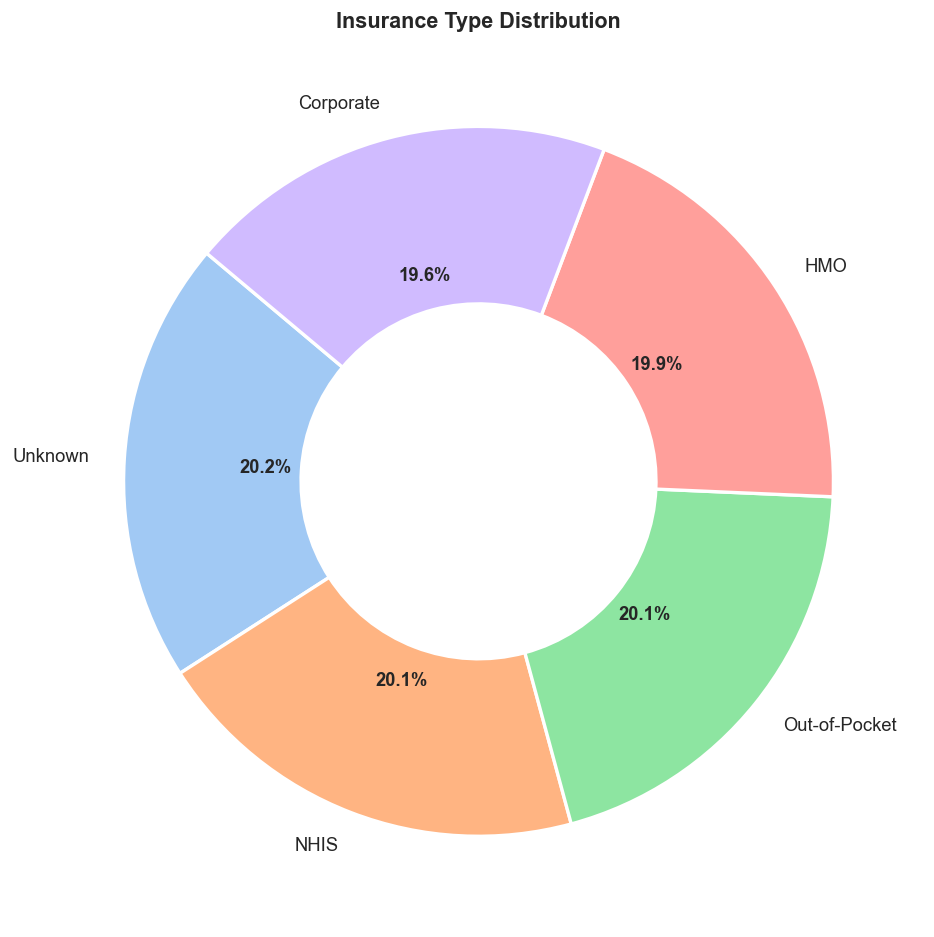

In [10]:
# ================================================
# Task 58 — Pie Chart: Insurance Type Distribution
# Shows how patients are covered across insurance types
# ================================================

# Count patients per insurance type
insurance_counts = df['insurance_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    insurance_counts.values,
    labels=insurance_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    wedgeprops=dict(width=0.5, 
                    edgecolor='white', 
                    linewidth=2)
)

# Make percentage text bigger
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Insurance Type Distribution', 
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

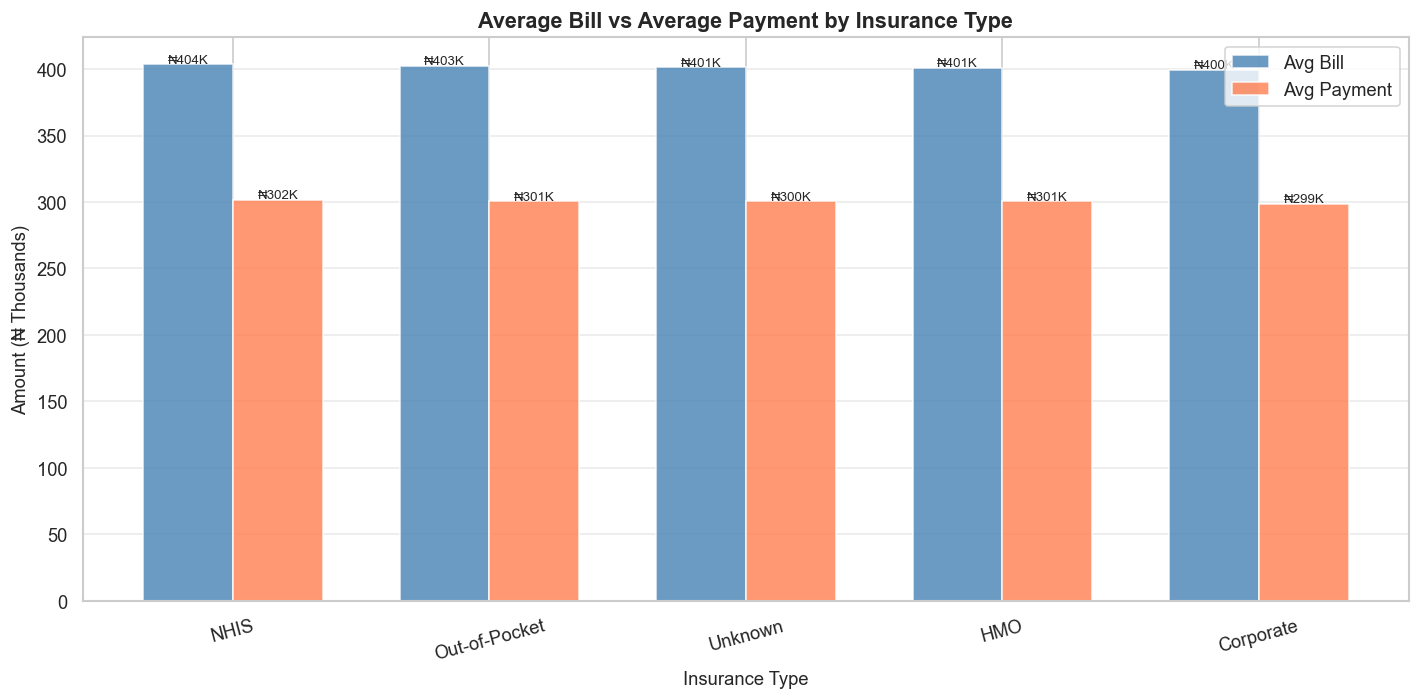

In [11]:
# ================================================
# Task 59 — Bar Chart: Avg Bill vs Avg Payment 
# by Insurance Type
# Compares what is billed vs what is actually paid
# ================================================

# Calculate average bill and payment per insurance type
insurance_billing = (df.groupby('insurance_type')
                     .agg(avg_bill=('total_bill_ngn', 'mean'),
                          avg_paid=('amount_paid_ngn', 'mean'))
                     .reset_index()
                     .sort_values('avg_bill', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))

# Set bar positions
x = range(len(insurance_billing))
width = 0.35

# Plot two bars side by side
bars1 = ax.bar([i - width/2 for i in x], 
               insurance_billing['avg_bill'] / 1e3,
               width=width, label='Avg Bill', 
               color='steelblue', alpha=0.8)

bars2 = ax.bar([i + width/2 for i in x], 
               insurance_billing['avg_paid'] / 1e3,
               width=width, label='Avg Payment', 
               color='coral', alpha=0.8)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'₦{bar.get_height():.0f}K',
            ha='center', fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'₦{bar.get_height():.0f}K',
            ha='center', fontsize=8)

ax.set_title('Average Bill vs Average Payment by Insurance Type',
             fontweight='bold')
ax.set_xlabel('Insurance Type')
ax.set_ylabel('Amount (₦ Thousands)')
ax.set_xticks(x)
ax.set_xticklabels(insurance_billing['insurance_type'], 
                   rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()


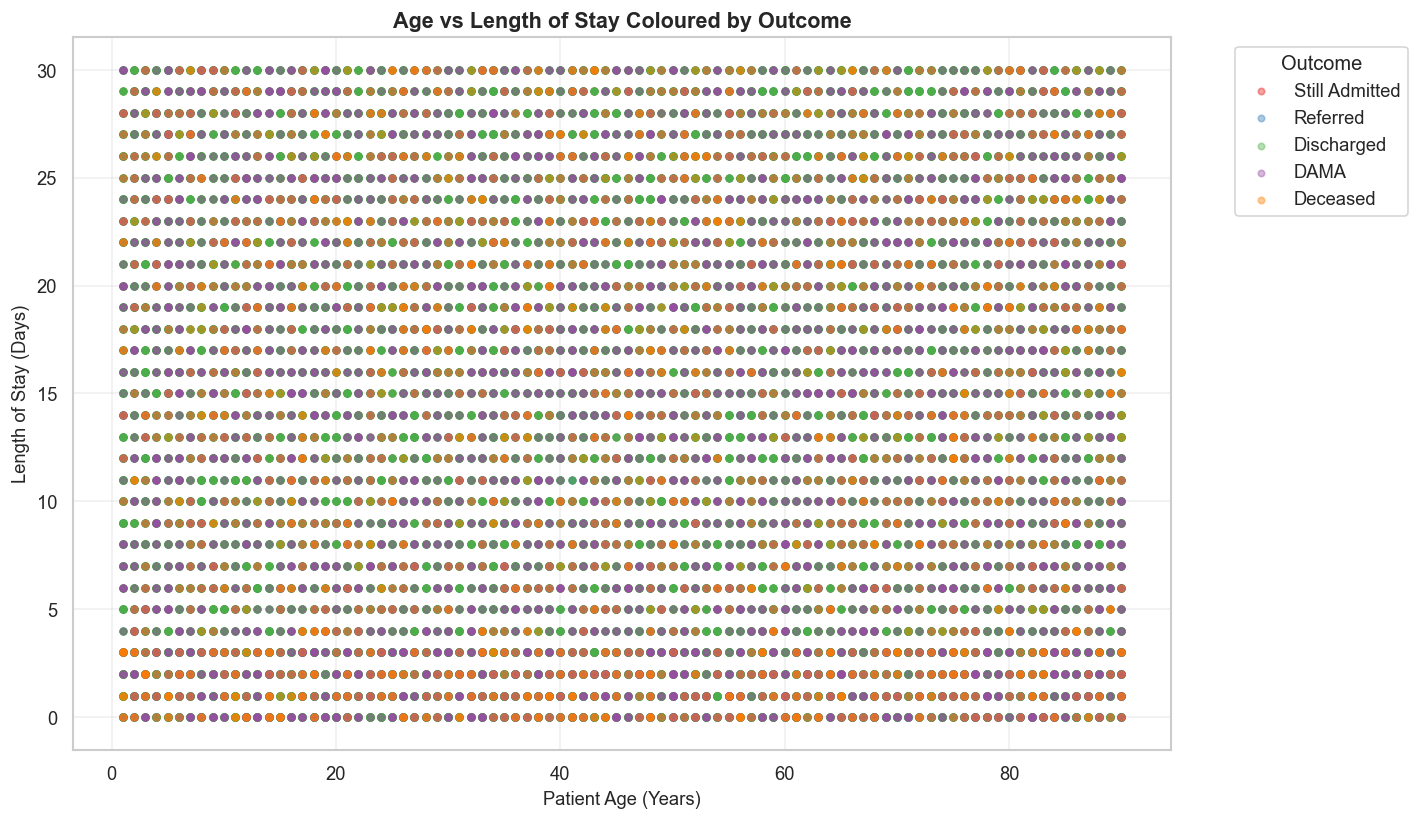

In [12]:
# ================================================
# Task 60 — Scatter Plot: Age vs Length of Stay
# Coloured by outcome to show relationship patterns
# ================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Get unique outcomes and assign colours
outcomes = df['outcome'].unique()
colours = sns.color_palette('Set1', len(outcomes))

for outcome, colour in zip(outcomes, colours):
    subset = df[df['outcome'] == outcome]
    ax.scatter(subset['age'], 
               subset['length_of_stay_days'],
               label=outcome,
               color=colour,
               alpha=0.4,
               s=15)

ax.set_title('Age vs Length of Stay Coloured by Outcome',
             fontweight='bold')
ax.set_xlabel('Patient Age (Years)')
ax.set_ylabel('Length of Stay (Days)')
ax.legend(title='Outcome', 
          bbox_to_anchor=(1.05, 1),
          loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Task 61 — 5 Operational Insights

**Insight 1 — Pediatrics is the Busiest Department**
Pediatrics recorded the highest admissions at 7,641.
The department requires priority staffing, bed allocation,
and medical supplies to meet demand.

**Insight 2 — Peak Admission Times Identified**
Friday at 5PM and Saturday at 1AM both recorded 401 admissions.
Hospital management should ensure maximum staffing at
these specific time windows every week.

**Insight 3 — Systemic Payment Collection Problem**
Every insurance type underpays by approximately 25% resulting
in a total bill gap of over ₦6 billion. Stronger payment
enforcement policies are needed across all insurance categories.

**Insight 4 — Emergency Department Manages Flow Well**
Emergency has the shortest length of stay at 1-3 days while
all other departments average 10-25 days. This reflects
appropriate acute care management in the emergency unit.

**Insight 5 — Pediatric Mortality Needs Investigation**
Deceased cases in Pediatrics are alarmingly close to Neurology
despite children generally having better survival rates.
Management should urgently review child mortality causes
and care quality standards.

In [13]:
# ================================================
# Save clean CSV with only original 17 columns
# Removing extra engineered columns before export
# ================================================

# Select only the original 17 columns
original_columns = ['patient_id', 'age', 'gender', 
                    'state_of_origin', 'department', 
                    'diagnosis', 'admission_date', 
                    'admission_time', 'discharge_date', 
                    'length_of_stay_days', 'outcome', 
                    'insurance_type', 'total_bill_ngn', 
                    'amount_paid_ngn', 'attending_doctor_id', 
                    'ward', 'readmitted']

df_sql = df[original_columns].copy()

# Save for SQL import
df_sql.to_csv('hospital_sql_import.csv', index=False)
print("SQL import CSV saved successfully!")
print("Rows:", len(df_sql))
print("Columns:", df_sql.columns.tolist())

SQL import CSV saved successfully!
Rows: 59950
Columns: ['patient_id', 'age', 'gender', 'state_of_origin', 'department', 'diagnosis', 'admission_date', 'admission_time', 'discharge_date', 'length_of_stay_days', 'outcome', 'insurance_type', 'total_bill_ngn', 'amount_paid_ngn', 'attending_doctor_id', 'ward', 'readmitted']


In [14]:
# ================================================
# Save clean CSV for Excel import
# Project 2: Hospital Patient Flow Analysis
# ================================================

df.to_csv('hospital_patient_flow_excel.csv', index=False)
print("CSV saved successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

CSV saved successfully!
Rows: 59950
Columns: 23
